In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from astropy.io import fits
import os
import shutil


### Inspección y organización de archivos FITS

El primer paso en el proceso de reducción consiste en inspeccionar los archivos FITS y organizarlos según su tipo.

Cada archivo FITS contiene información en su header que describe las condiciones de observación. En particular, la palabra `IMAGETYP` permite clasificar las imágenes en:

- Bias frames  
- Dark frames  
- Flat-field frames  
- Science (light) frames  

Utilizando esta información, el dataset se separa en diferentes carpetas, lo que permite mantener una estructura ordenada y facilita el flujo de trabajo durante el proceso de reducción.

In [2]:
Arxiv = "/home/noam/Escritorio/Proyecto 1/test/"

#Utilizamos comando os.listdir para nombrar los archivos fit
file_list= os.listdir(Arxiv)
#Agregamos un contador para hacer el histograma del primer Bias Frame que nos encontremeos


Bias_f = []
Dark_f = []
Flat_f = []
Light_f = []

b = 0
d = 0
f = 0
l = 0
#Ahora comenzamos la exploracion de los archivos
for file in file_list:

    filepath = os.path.join(Arxiv, file)


    with fits.open(filepath) as hdul:

        image_data = hdul[0].data
        header = hdul[0].header
        tipo = header["IMAGETYP"]

        if tipo == "Bias Frame":
            folder = "Bias"
            b += 1
            Bias_f.append(image_data)

        elif tipo == "Dark Frame":
            folder = "Dark"
            d += 1
            Dark_f.append(image_data)

        elif tipo == "Flat Field":
            folder = "Flat"
            f += 1
            Flat_f.append(image_data)

        else:
            folder = "Light"
            l += 1
            Light_f.append(image_data)

    # crear carpeta
    destino = os.path.join(Arxiv, folder)
    os.makedirs(destino, exist_ok=True)

    # mover archivo
    shutil.move(filepath, os.path.join(destino, file))
#Al final logramos contar la cantidad de archivos y que tipo de contenido tienen cada una

print("Se tienen", b, "Bias Frame,", d, "Dark Frame,", f, "Flat Field,", l, "Light Frame")

Se tienen 9 Bias Frame, 3 Dark Frame, 4 Flat Field, 3 Light Frame


### Lectura y organización del dataset

Se inspeccionaron los headers de los archivos FITS para identificar las keywords relevantes, en particular `IMAGETYP`, lo que facilito clasificarlas imágenes en bias, dark, flat y light frames.

Luego, los archivos fueron organizados en directorios separados según su tipo. Esto es importante para asegurar un trabajo claro y eficiente, ya que en el proceso de reducción se necesita acceder a tipos específicos de imágenes.

El dataset contiene:

- Bias frames: 9
- Dark frames: 3
- Flat-field frames: 4
- Science frames: 3

Esta estructura permite facilitar la construcción de los marcos de calibración en las siguientes etapas del proceso.

In [3]:
Bias_A = np.array(Bias_f)
# Aqui solo creamos las dirrecciones de las carpetas que 
# usaremos mas adelante para la lectura de los archivos

Arxiv_B = Arxiv + str("Bias/")
Arxiv_D = Arxiv + str("Dark/")
Arxiv_F = Arxiv + str("Flat/")
Arxiv_L = Arxiv + str("Light/")


### Exploración de los Bias Frames

Para ver los valores del ruido electrónico que hay en el detector, se analiza la distribución de los valores de píxeles en un bias frame.

Un bias frame corresponde a una imagen tomada con tiempo de exposición cero, por lo que su contenido refleja únicamente el offset electrónico generado durante la lectura de la CCD.

El histograma de los valores de píxeles permite visualizar esta distribución.

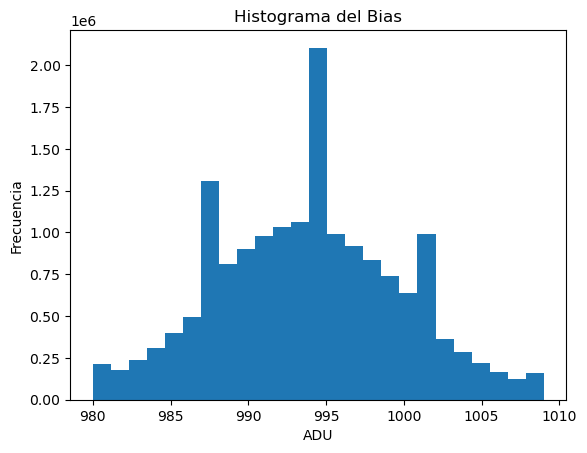

In [32]:

file_list= os.listdir(Arxiv_B)

n = 0
#Exploramos la varpeta de Bias prar printear la primera imagen en un histograma
for i in file_list:


    with fits.open(Arxiv_B + str(i)) as hdul:


        image_data = hdul[0].data
        hdul[0].header
        

        
        if hdul[0].header["IMAGETYP"] == "Bias Frame" and n == 0:
            histogram = plt.hist(image_data.flatten(), bins=25, range=np.percentile(image_data, [1,99]))
            n = n + 1

plt.title("Histograma de un Bias")
plt.xlabel("ADU")
plt.ylabel("Frecuencia")

plt.show()

### Análisis del histograma

El histograma muestra la distribución de los valores de píxeles del bias frame, la cual se concentra en torno a un valor.

Esta distribución representa el offset electrónico igenerada por la CCD durante el proceso de lectura, incluso en tiempo de exposicion 0.

La forma aproximadamente gaussiana del histograma indica que las fluctuaciones alrededor del valor medio están dominadas por ruido electrónico (readout noise).

La dispersión de la distribución está directamente relacionada con la magnitud de este ruido, mientras que el valor medio corresponde al nivel de bias que deberá ser considerado en las correcciones posteriores.

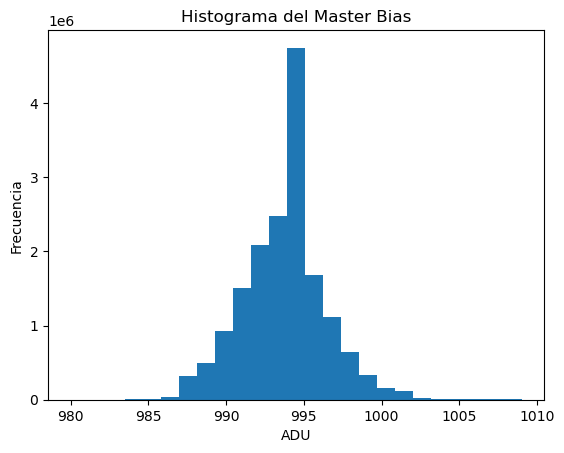

In [31]:

Master_Bias = np.median(Bias_A, axis=0)

 #Luego de crear el Master Bias ploteamos su histograma

histogram = plt.hist(Master_Bias.flatten(), bins=25, range=np.percentile(Bias_A, [1,99]))
plt.title("Histograma del Master Bias")
plt.xlabel("ADU")
plt.ylabel("Frecuencia")

plt.show()

### Construcción del Master Bias

Para construir el Master Bias, combinamos todos los bias frames en una sola imagen.

En este caso usamos la **mediana** píxel a píxel, porque es menos sensible a valores raros (por ejemplo píxeles defectuosos) que podrían afectar el resultado si usamos el promedio.

El Master Bias representa el nivel de señal base del CCD.

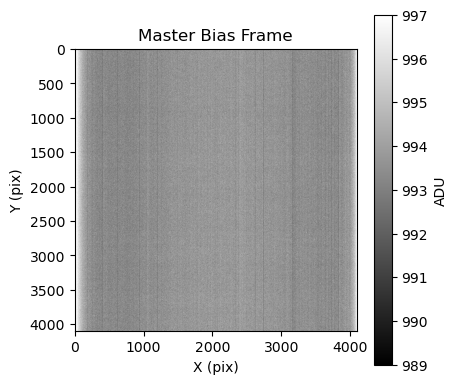

In [30]:


# Visualizamos las imágenes master

plt.figure(figsize=(10, 10))


Rango_min = np.percentile(Master_Bias, 5)
Rango_max = np.percentile(Master_Bias, 87)
plt.subplot(2, 2, 1)
plt.imshow(Master_Bias, cmap='gray', vmin=Rango_min, vmax=Rango_max)

plt.title("Master Bias Frame")
plt.xlabel("X (pix)")
plt.ylabel("Y (pix)")

cbar = plt.colorbar()
cbar.set_label("ADU")

### Análisis

La imagen del Master Bias es bastante uniforme, lo que es esperable ya que representa el offset electrónico de la CCD.

No se observan estructuras grandes, solo pequeñas variaciones debidas al ruido. Esto indica que el bias es bastante estable en toda la CCD.

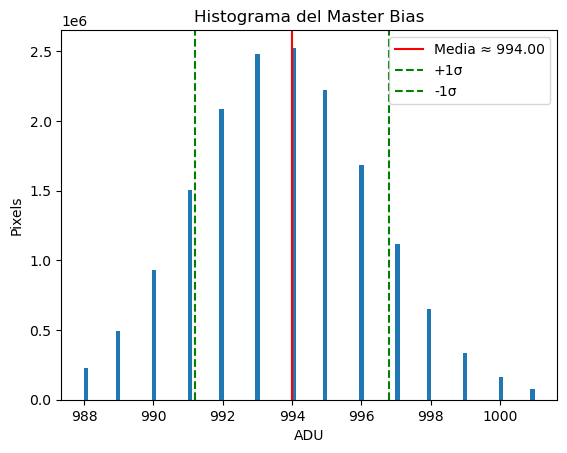

Valor central: 994.0
Desviación estándar: 2.7950340529256215


In [7]:
# Cálculo de estadísticos
mean = np.median(Master_Bias)  
std = np.std(Master_Bias)

# Aqui generamos el histograma
plt.figure()

plt.hist(    Master_Bias.flatten(), bins=100, range=np.percentile(Master_Bias, [1, 99])
)

# Líneas correspondientes a la mediana, y las desviaciones
plt.axvline(mean, color='red', label=f"Media ≈ {mean:.2f}")
plt.axvline(mean + std, color='green', linestyle='--', label=f"+1σ")
plt.axvline(mean - std, color='green', linestyle='--', label=f"-1σ")

# aqui ponemos titulos y nombres a los ejes
plt.xlabel("ADU")
plt.ylabel("Pixeles")
plt.title("Histograma del Master Bias")
plt.legend()

plt.show()

print("Valor central:", mean)
print("Desviación estándar:", std)

### Análisis

El histograma muestra una distribución con poca deviacion, que corresponde al nivel de bias del detector.

La desviación estándar mide la dispersión de los valores y está asociada al ruido electrónico.

Al tener poca desvviacion podemos decir que el ruido es bajo y que la combinación de múltiples bias frames permitió mejorar la estimación del nivel de bias.

### Inspección de los Dark Frames

Se revisan los dark frames para identificar sus tiempos de exposición (`EXPTIME`), ya que este valor importante para su calibración.

El tiempo de exposición nos dara cuánto ruido térmico se acumulaen cada imagen, por lo que debe ser considerado al construir el Master Dark.

In [8]:
file_list= os.listdir(Arxiv_D)
#Aqui realiazmos la misma revicion que para los Bias pero enfocada en los Dark Frames
n = 0
for i in file_list:

    
    with fits.open(Arxiv_D + str(i)) as hdul:
        
        
        image_data = hdul[0].data
        header = hdul[0].header
        
        B#uscamos el tiempo de exposicion
        if header["IMAGETYP"] == "Dark Frame":
            print("Para el archivo",file_list[n], "se tienen" ,header['EXPTIME'], "seg de exposicion")
            n = n + 1
        else:
            n = n + 1


Para el archivo image8.fit se tienen 180.0 seg de exposicion
Para el archivo image11.fit se tienen 240.0 seg de exposicion
Para el archivo image2.fit se tienen 200.0 seg de exposicion


### Análisis

Los dark frames presentan distintos tiempos de exposición los cuales estaremos utilizando para la construccion del Master Dark


### Construcción del Master Dark

Los Dark Frames miden el ruido termico por lo cual para la construccion de cada imagen se corrige restando el Master Bias y dividiendo por su tiempo de exposición:

$$
D_i^{\text{corr}} = \frac{D_i - \mathrm{MasterBias}}{\mathrm{EXPTIME}_i}
$$

De esta forma se obtiene el ruido en unidades de [ADU/segundo], lo que permite comparar imágenes con distintos tiempos.



In [9]:
file_list= os.listdir(Arxiv_D)
n = 0
#Volvemos a explorar los archibos pero ahora para construir el Master Dark

Black_f = []
for i in file_list:

   
    with fits.open(Arxiv_D + str(i)) as hdul:
        
        
        image_data = hdul[0].data
        header = hdul[0].header
        
        
        if header["IMAGETYP"] == "Dark Frame":
            seg = float(header["EXPTIME"])
            data = (image_data - Master_Bias)/seg
            
            n = n + 1
            mean = np.median(data.flatten())

            #Aqui reviso si es que el Dark Frame es utilizable o generaria errores para las mediciones
            if mean >= 0:
                Black_f.append(data)
                
        else:
            n = n + 1

Dark_A = np.array(Black_f)
Master_D = np.median(Dark_A, axis=0)


### Análisis

Primero se corrigen los dark frames para eliminar el bias y normalizarlos por el tiempo de exposición.

Después, se filtran los datos para evitar incluir imágenes con valores que puedan generar errores en los calculos, luego los datos se juntan en una lista.


### ¿Por que tenemos que usar el EXPTIME?

Porque el ruido térmico crece con el tiempo. Al dividir por el tiempo de exposición, se obtiene una medida en ADU/segundo, lo que permite comparar y combinar correctamente los dark frames.

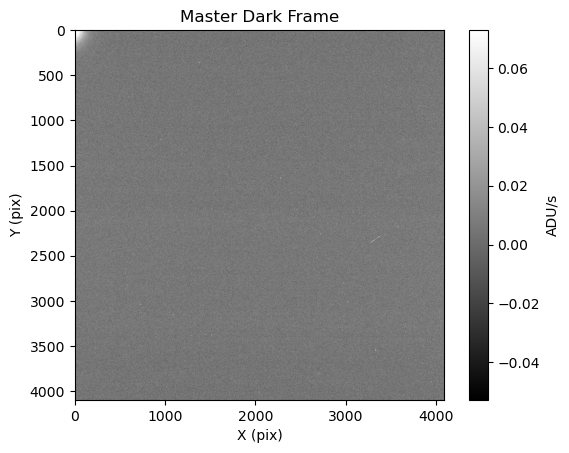

In [29]:
#Ahora mostramos la imagen del Master Dark

Rango_d = np.percentile(Master_D, [1,99])

plt.imshow(Master_D, cmap='gray', vmin=Rango_d[0], vmax=Rango_d[1])

plt.title("Master Dark Frame")
plt.xlabel("X (pix)")
plt.ylabel("Y (pix)")

cbar = plt.colorbar()
cbar.set_label("ADU/s")

### Análisis

El Master Dark muestra la distribución del ruido térmico en el detector.

A diferencia del bias, aquí vemos estructuras como píxeles calientes o variaciones espaciales, ya que el ruido térmico no es completamente uniforme.

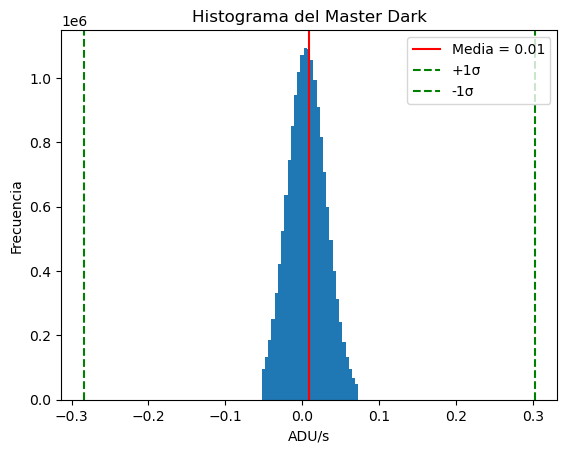

Media: 0.00917004251645671
Desviación estándar: 0.29299984518602007


In [40]:
# Aplicamos la misma logica que para el ploteo del histograma del Master Bias

mean_value_d = np.mean(Master_D.flatten())
std_value_d = np.std(Master_D.flatten())




plt.hist(Master_D.flatten(), bins=30,range=np.percentile(Master_D, [1, 99]))


plt.axvline(mean_value_d, color='r', label=f"Media = {mean_value_d:.2f}")
plt.axvline(mean_value_d + std_value_d, color='g', linestyle='--', label="+1σ")
plt.axvline(mean_value_d - std_value_d, color='g', linestyle='--', label="-1σ")


plt.xlabel("ADU/s")
plt.ylabel("Frecuencia")
plt.title("Histograma del Master Dark")
plt.legend()

plt.show()

print("Media:", mean_value_d)
print("Desviación estándar:", std_value_d)


### Análisis del Master Dark

El histograma muestra la distribución del ruido térmico del detector.

El valor medio representa la cantidad promedio de señal térmica por segundo (ADU/s), mientras que la desviación estándar indica la dispersión del ruido.

Aunque la desviacion estaqndar aparenta estar alejada, esto debido a posibles pixels erroneos, podemos ver que la distribucion se mantiene angosta y homogenea lo que indica que el ruido térmico es bastante uniforme.

### Estimación de ADU por segundo

El valor medio del Master Dark corresponde a la cantidad de ADU generadas por segundo generado por el ruido térmico del detector.

Por lo tanto, se obtiene que:

ADU/s ≈ 0.00917004251645671

### Inspección de Flat Frames

Se visualizan varios flat frames para identificar características.

Los flats permiten observar efectos como variaciones de sensibilidad, viñeteo o sombras de polvo en el sistema.

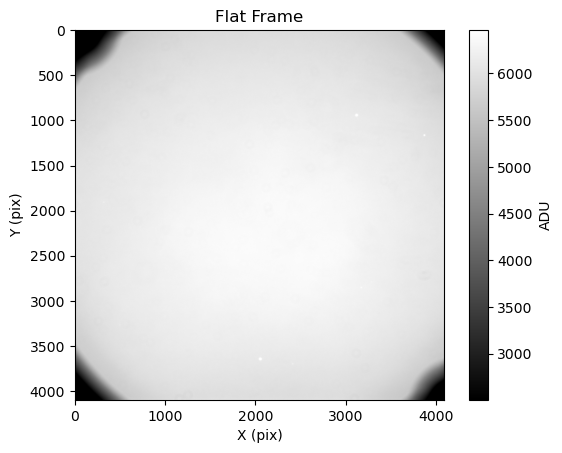

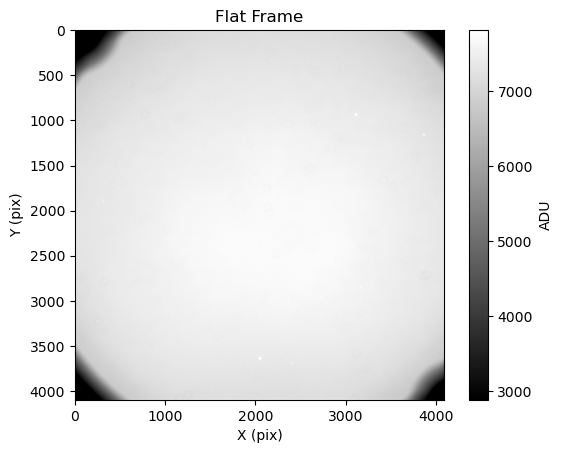

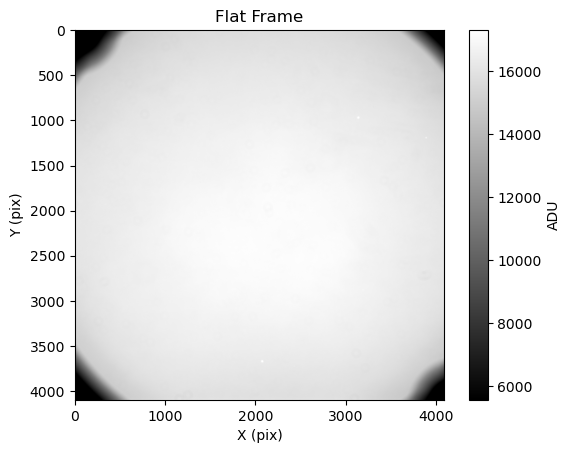

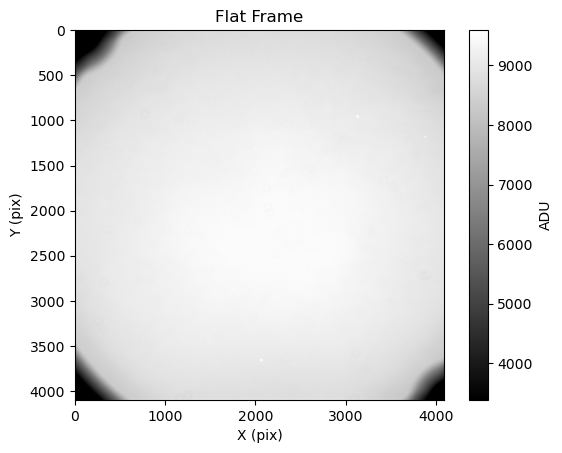

In [28]:
file_list= os.listdir(Arxiv_F)

 #Comenzamos con la exploracion de los FLat, mantenemos la misma logica de exploracion ya vista con los anteriores casos
for i in file_list:

    with fits.open(Arxiv_F + str(i)) as hdul:

        image_data = hdul[0].data
        header = hdul[0].header

        if header["IMAGETYP"] == "Flat Field":

            data_min = np.percentile(image_data, 1)
            data_max = np.percentile(image_data, 99)

            plt.imshow(image_data, cmap='gray', vmin=data_min, vmax=data_max)

            plt.title("Flat Frame")
            plt.xlabel("X (pix)")
            plt.ylabel("Y (pix)")

            cbar = plt.colorbar()
            cbar.set_label("ADU")

            plt.show()

### Análisis

En los flat frames se observan variaciones de intensidad a lo largo de la imagen.

Estas pueden deberse a efectos como:
- viñeteo (esquinas con menos iluminacion),
- diferencias de sensibilidad entre píxeles,
- sombras producidas por polvo en el sistema óptico.

Estas estructuras justifican la utilizacion de los Flats en el proceso de reducción.

Text(0, 0.5, 'Frecuencia')

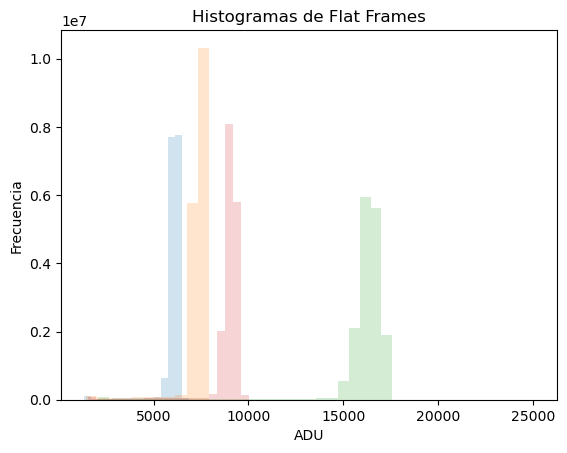

In [27]:


#Aqui buscamos plotear todos los histogrramas de los flats

flat_data = []

file_list= os.listdir(Arxiv_F)

for i in file_list:

    with fits.open(Arxiv_F + str(i)) as hdul:

        image_data = hdul[0].data
        header = hdul[0].header

        if header["IMAGETYP"] == "Flat Field":
            plt.hist(image_data.flatten(), bins=40,alpha = 0.2)
            

plt.title("Histogramas de Flat Frames")
plt.xlabel("ADU")
plt.ylabel("Frecuencia")


### Análisis

Los histogramas muestran cómo se distribuyen los valores de píxeles en cada flat frame.

Se observa que no todos los flats tienen la misma distribución, lo que puede deberse a diferencias en el filtro, en la iluminación o en las condiciones de observación.

Por esta razón, no es correcto combinar todos los flats directamente. Es necesario seleccionar solo aquellos que sean comparables (por ejemplo, mismo filtro y condiciones similares).

Esto para que el Master Flat represente correctamente la interaccion con el sistema óptico.

Text(0, 0.5, 'Frecuencia')

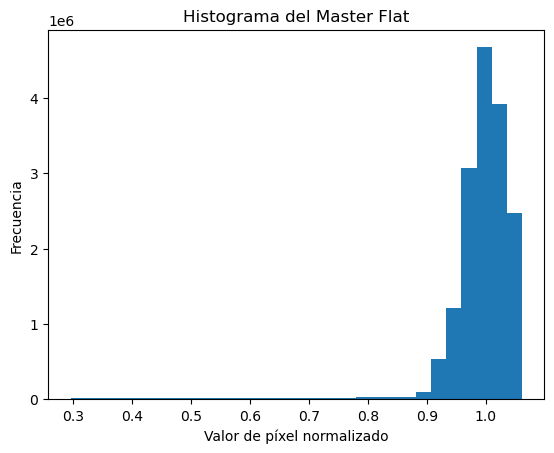

In [35]:

#Aqui usando la misma manera de exploracion comen zamos con la creacion del Master FLat
file_list = os.listdir(Arxiv_F)
Flat_f = []

for file in file_list:

    with fits.open(Arxiv_F + file) as hdul:
        
        image_data = hdul[0].data
        header = hdul[0].header
        
        if header["IMAGETYP"] == "Flat Field":
            
            seg = float(header["EXPTIME"])
            
            # Corrección
            data = (image_data - Master_Bias - Master_D * seg)
            
            # Normalización por el propio flat
            mean = np.median(image_data)
            data = data / mean

            Flat_f.append(data)

Flat_A = np.array(Flat_f)


Master_F = np.median(Flat_A, axis=0)

# Normalización final
Master_F = Master_F / np.median(Master_F)

# Histograma
plt.hist(Master_F.flatten(),bins=30,range=np.percentile(Master_F, [1, 99]))
plt.title("Histograma del Master Flat")
plt.xlabel("Valor de píxel normalizado")
plt.ylabel("Frecuencia")

### Selección de flat frames

Idealmente, los flat frames deben seleccionarse considerando que tengan el mismo filtro y condiciones de iluminación.

En este caso, se utilizaron todos los flats disponibles. Aunque esto puede introducir pequeñas inconsistencias si existen diferencias entre ellos, la normalización aplicada reduce en gran parte estos efectos.

Para un análisis más riguroso, sería lo mejor para seleccionar solo flats homogéneos.

### Análisis

El Master Flat muestra la respuesta general del detector y del sistema óptico.

La normalización permite que el valor medio sea cercano a 1, lo que facilita su uso en la corrección de las imágenes.

Las variaciones en el Master Flat corresponden a efectos como viñeteo, diferencias de sensibilidad entre píxeles y sombras de polvo.

### Reducción de la imagen científica

La imagen se corrige aplicando bias, dark y flat:

$$
\mathrm{Image}_{corr} = \frac{\mathrm{Image} - \mathrm{MasterBias} - \mathrm{MasterDark} \cdot \mathrm{EXPTIME}}{\mathrm{MasterFlat}}
$$

Esto permite eliminar efectos instrumentales y mejorar la calidad de la imagen.

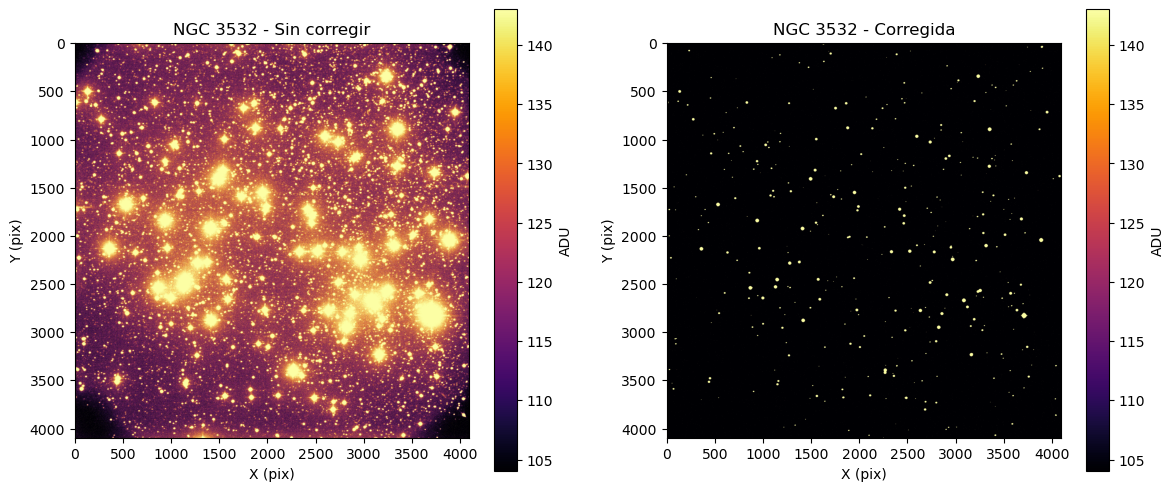

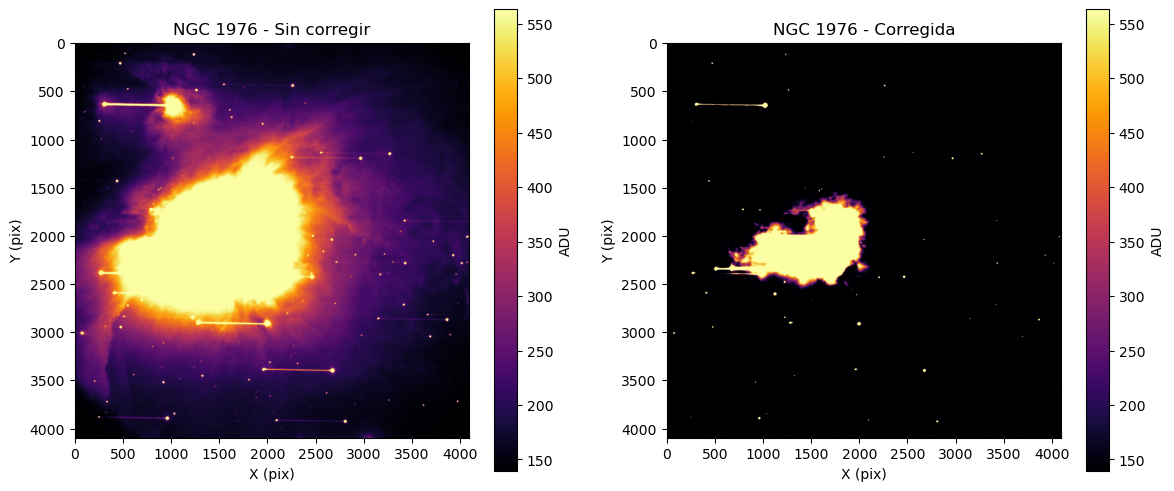

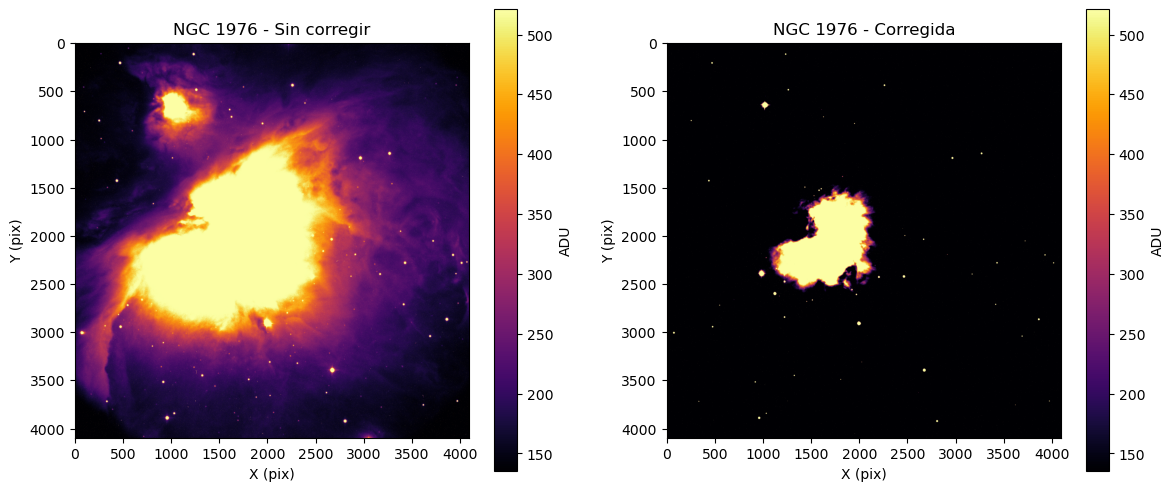

In [37]:

#Aqui utilice IA para el ploting de las imagenes
#ya que no sabia como hacer que se vieran en parejas
file_list = os.listdir(Arxiv_L)

#Seguimos explroando los archivos como vimos anteriormente

for file in file_list:

    with fits.open(Arxiv_L + file) as hdul:

        image_data = hdul[0].data
        header = hdul[0].header

        if header["IMAGETYP"] == "Light Frame":

            #Aqui realizamos las correcciones
            
            seg = header["EXPTIME"]
            data = (image_data - Master_Bias - Master_D * seg) / Master_F
            
            nombre = header["OBJECT"]

            vmin = np.percentile(image_data, 5)
            vmax = np.percentile(image_data, 87)

            fig, axs = plt.subplots(1, 2, figsize=(14, 6))

            im0 = axs[0].imshow(image_data, cmap='inferno', vmin=vmin, vmax=vmax)
            axs[0].set_title(f"{nombre} - Sin corregir")
            axs[0].set_xlabel("X (pix)")
            axs[0].set_ylabel("Y (pix)")

            cbar0 = plt.colorbar(im0, ax=axs[0])
            cbar0.set_label("ADU")


            im1 = axs[1].imshow(data, cmap='inferno', vmin=vmin, vmax=vmax)
            axs[1].set_title(f"{nombre} - Corregida")
            axs[1].set_xlabel("X (pix)")
            axs[1].set_ylabel("Y (pix)")

            cbar1 = plt.colorbar(im1, ax=axs[1])
            cbar1.set_label("ADU")

### Análisis

La imagen corregida muestra un fondo más uniforme y una mejor definición del objeto en comparación con la imagen original.

Las correcciones de bias, dark y flat eliminan los efectos instrumentales, permitiendo observar con mayor claridad la estructura del objeto astronómico.

### ¿Que observamos en las imagenes?
En el caso de NGC 3532 se observa un conjunto de estrellas bien definido, mientras que NGC 1976 presenta una estructura difusa siendo esta una nebulosa.

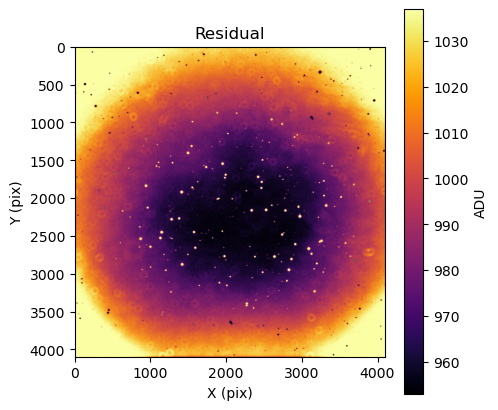

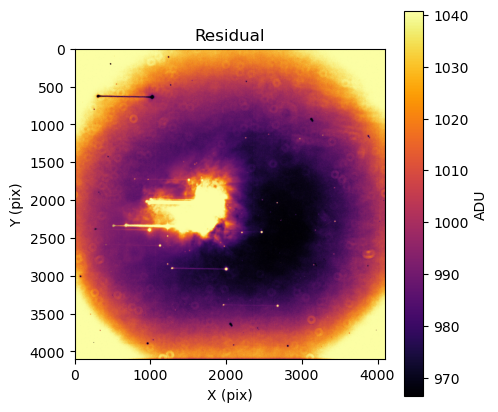

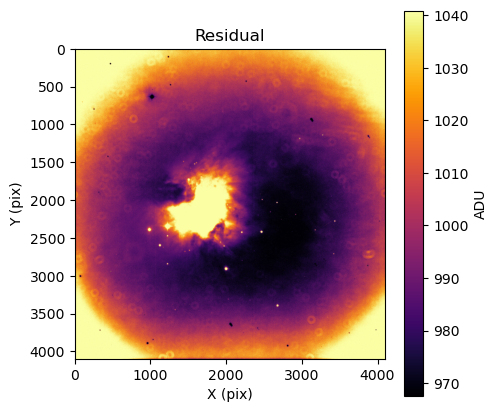

In [39]:

#Realizamos el mismo procedimiento pero para la construccion de los residuals
for i in file_list:

    with fits.open(Arxiv_L + str(i)) as hdul:

        image_data = hdul[0].data
        header = hdul[0].header

        
        if header["IMAGETYP"] == "Light Frame":

            seg = header["EXPTIME"]
            
            data = (image_data - Master_Bias - Master_D*seg)/Master_F

            #Realizamos la resta de la imagen corregida y la imagen raw
            
            res = image_data - data
            
            data_min = np.percentile(res, 5)
            data_max = np.percentile(res, 87)            
            
                     
            plt.figure(figsize=(5, 5))  # <-- tamaño más chico

            plt.imshow(res, cmap='inferno', vmin=data_min, vmax=data_max)

            plt.title("Residual")
            plt.xlabel("X (pix)")
            plt.ylabel("Y (pix)")

            cbar = plt.colorbar()
            cbar.set_label("ADU")

            plt.show()

### Análisis del residual

El residual muestra las diferencias entre la imagen original y la corregida.

Se observan principalmente efectos instrumentales eliminados en el proceso, como el offset electrónico (bias), el ruido térmico (dark) y las variaciones de sensibilidad del detector (flat).

Con esto podemos ver que las correcciones que realizamos fueron efectivas y que realmente apreciamos una mejora en la imagen.